In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sys
import os

project_root = os.path.dirname(os.path.abspath(''))
if project_root not in sys.path:
    sys.path.append(project_root)

# from FEATURES.features import *
from BACKTEST.backtestCalculateEVS import *
from BACKTEST.backtest import backtestTrios, calculate3LegMetrics
# from MODELS.teamInfo import *

In [2]:
import joblib

# Load NGBoost mean and variance models
mean_model = joblib.load('../MODELS/SAVED_MODELS/NGBOOST_PTS_MEAN_MODEL_BACKTEST.pkl')
variance_model = joblib.load('../MODELS/SAVED_MODELS/NGBOOST_PTS_VAR_MODEL_BACKTEST.pkl')
calibration_factor = joblib.load('../MODELS/SAVED_MODELS/NGBOOST_PTS_CALIBRATION_FACTOR_BACKTEST.pkl')

models = {
    'mean': mean_model,
    'variance': variance_model,
    'calibration_factor': calibration_factor,
}

features = joblib.load('../MODELS/SAVED_MODELS/feature_list.pkl')

print(f"Loaded NGBoost models with calibration factor: {calibration_factor}")
print(f"Number of features: {len(features)}")

Loaded NGBoost models with calibration factor: 4.5
Number of features: 170


In [5]:
pd.set_option('display.max_columns', None)

s25 = pd.read_csv('../DATA/CSV_FILES/TRAIN_DATA/PTS_TRAIN_25.csv')
# s24_pts = pd.read_csv('../DATA/CSV_FILES/TRAIN_DATA/PTS_TRAIN_24.csv')
# s26 = pd.read_csv('../DATA/CSV_FILES/TRAIN_DATA/PTS_TRAIN_26.csv')


In [6]:
backtestData = pd.read_csv('../DATA/CSV_FILES/BACKTEST_DATA/dfs_data.csv')
backtestData = backtestData[(backtestData['BOOKMAKER'] == 'underdog') &  (backtestData['CATEGORY'] == 'player_points')]
backtestData.sample(5)

/var/folders/9q/5_554qsx5z70w9d_vkmvjg0h0000gn/T/ipykernel_95108/3488731641.py:1: DtypeWarning: Columns (11,12,14) have mixed types. Specify dtype option on import or set low_memory=False.
  backtestData = pd.read_csv('../DATA/CSV_FILES/BACKTEST_DATA/dfs_data.csv')


,Unnamed: 0.2,Unnamed: 0.1,Unnamed: 0,NAME,CATEGORY,BOOKMAKER,SIDE,LINE,ODDS,HOME_TEAM,AWAY_TEAM,game_id,commence_time,GAME_DATE,period_id,fair_line,fair_odds,OVER/ODDS
176712,176712,176712,92697,Jaylen Wells,player_points,underdog,over,8.5,-137,Miami Heat,Memphis Grizzlies,NaN,NaN,2025-04-03,game,9.5,117.0,over
130847,130847,130847,33760,Corey Kispert,player_points,underdog,over,11.5,-137,Detroit Pistons,Washington Wizards,NaN,NaN,2025-03-13,game,11.5,109.0,over
57364,57364,57364,57364,Jayson Tatum,player_points,underdog,over,25.5,-137,Philadelphia 76ers,Boston Celtics,NaN,NaN,2025-02-02,game,28.5,116.0,over
20719,20719,20719,20719,Shai Gilgeous-Alexander,player_points,underdog,under,30.5,-137,Los Angeles Lakers,Oklahoma City Thunder,363cc300fd430fdf4510ff652bc54ef7,2024-11-30T03:10:00Z,2024-11-29,NaN,NaN,NaN,under
179383,179383,179383,96060,Shai Gilgeous-Alexander,player_points,underdog,under,32.5,-137,Houston Rockets,Oklahoma City Thunder,NaN,NaN,2025-04-05,game,27.5,-141.0,under


In [ ]:
# backtestData= pd.read_csv('../DATA/CSV_FILES/BACKTEST_DATA/s26props.csv')
# s26_other = pd.read_csv('../DATA/CSV_FILES/PROP_DATA/PLAYER_LINES/NBA_DFS_20251106.csv')
# s26_other1 = pd.read_csv('../DATA/CSV_FILES/PROP_DATA/PLAYER_LINES/NBA_DFS_20251107.csv')
# backtestData = pd.concat([backtestData, s26_other, s26_other1])

# backtestData = backtestData[(backtestData['BOOKMAKER'] == 'Underdog') &  
#                             (backtestData['CATEGORY'] == 'player_points')]
# backtestData.rename(columns={'COMMENCE_TIME': 'GAME_DATE', 'OVER/UNDER': 'SIDE'}, inplace=True)
# backtestData

,Unnamed: 0,BOOKMAKER,CATEGORY,NAME,SIDE,LINE,ODDS,GAME_DATE,LAST_UPDATE,version https://git-lfs.github.com/spec/v1
0,0.0,Underdog,player_points,Pascal Siakam,Over,26.5,-137.0,2025-10-31,2025-10-31T21:57:25Z,NaN
1,1.0,Underdog,player_points,Pascal Siakam,Under,26.5,-137.0,2025-10-31,2025-10-31T21:57:25Z,NaN
2,2.0,Underdog,player_points,Kristaps Porzingis,Over,18.5,-137.0,2025-10-31,2025-10-31T21:57:25Z,NaN
3,3.0,Underdog,player_points,Kristaps Porzingis,Under,18.5,-137.0,2025-10-31,2025-10-31T21:57:25Z,NaN
4,4.0,Underdog,player_points,Aaron Nesmith,Over,15.5,-137.0,2025-10-31,2025-10-31T21:57:25Z,NaN
...,...,...,...,...,...,...,...,...,...,...
583,NaN,Underdog,player_points,Isaiah Hartenstein,Under,9.5,-137.0,2025-11-08,2025-11-07T23:20:29Z,NaN
584,NaN,Underdog,player_points,Isaiah Joe,Over,12.5,-137.0,2025-11-08,2025-11-07T23:20:29Z,NaN
585,NaN,Underdog,player_points,Isaiah Joe,Under,12.5,-137.0,2025-11-08,2025-11-07T23:20:29Z,NaN
586,NaN,Underdog,player_points,Ajay Mitchell,Over,16.5,-137.0,2025-11-08,2025-11-07T23:20:29Z,NaN


In [7]:
date = '2024-11-04'

results = backtestTrios(s25, backtestData, date, models, features, edge_threshold=3.5, top_n=10, 
                 stat_col='PTS', stake=10, max_player_appearances = 1)

# Comprehensive results analysis
if not results.empty:
    print("=" * 60)
    print("TRIO BETTING RESULTS ANALYSIS")
    print("=" * 60)
    
    # Overall metrics
    total_bets = len(results)
    total_wins = results['parlay_won'].sum()
    win_rate = results['parlay_won'].mean()
    
    # Calculate profit/loss
    total_profit = results['parlay_profit'].sum() 
    avg_profit = results['parlay_profit'].mean() 
    
    print(f"Total Bets: {total_bets}")
    print(f"Wins: {total_wins}")
    print(f"Win Rate: {win_rate:.2%}")
    print(f"Total Profit: ${total_profit:.2f}")
    print(f"Average Profit per Bet: ${avg_profit:.2f}")

results

Pre-computing predictions for 146 players...
Error getting prediction for Giannis Antetokounmpo: No data found for player Giannis Antetokounmpo
Error getting prediction for Gary Trent Jr: No data found for player Gary Trent Jr
Error getting prediction for Andre Jackson Jr: No data found for player Andre Jackson Jr
Error getting prediction for Carlton Carrington: No data found for player Carlton Carrington
Error getting prediction for Isaiah Stewart II: No data found for player Isaiah Stewart II
Error getting prediction for Tim Hardaway Jr: No data found for player Tim Hardaway Jr
Error getting prediction for Jaren Jackson Jr: No data found for player Jaren Jackson Jr
Error getting prediction for Jimmy Butler: No data found for player Jimmy Butler
Error getting prediction for Jaime Jaquez Jr: No data found for player Jaime Jaquez Jr
Error getting prediction for Zach LaVine: No data found for player Zach LaVine
Error getting prediction for Lauri Markkanen: No data found for player Lauri 

,NAME 1,NAME 2,NAME 3,LINE 1,LINE 2,LINE 3,PREDICTION 1,PREDICTION 2,PREDICTION 3,MODEL SIDE 1,MODEL SIDE 2,MODEL SIDE 3,PROB 1,PROB 2,PROB 3,PROB ALL THREE,EDGE 1,EDGE 2,EDGE 3,COMBINED EDGE,EV$,KELLY FULL,RECOMMENDATION,CI 1,CI 2,CI 3,INTERVAL WIDTH 1,INTERVAL WIDTH 2,INTERVAL WIDTH 3,SIGMA 1,SIGMA 2,SIGMA 3,SIGMA FLAG 1,SIGMA FLAG 2,SIGMA FLAG 3,CORRELATION,SAME_GAME_PAIRS,EXPECTED ROI,actual1,actual2,actual3,leg1_won,leg2_won,leg3_won,parlay_won,parlay_recommendation,parlay_profit,date
0,Trae Young,Jalen Brunson,Miles Bridges,26.5,28.5,17.5,17.39,21.34,11.05,under,under,under,0.914,0.864,0.847,0.6016,0.336,0.285,0.268,0.475,26.09,0.522,1,"(4.3, 30.4)","(8.5, 34.1)","(0.0, 23.4)",None,None,None,6.66,6.53,6.31,High,High,High,0.1,0,260.9,2,29,10,1,0,1,0,1,-10.0,2024-11-04
1,Corey Kispert,LeBron James,Paul George,16.5,23.5,17.5,10.56,17.74,11.28,under,under,under,0.804,0.799,0.817,0.4722,0.226,0.221,0.239,0.331,18.33,0.367,1,"(0.0, 24.2)","(4.3, 31.2)","(0.0, 24.8)",None,None,None,6.95,6.88,6.88,High,High,High,0.1,0,183.3,4,20,15,1,1,1,1,1,50.0,2024-11-04
2,Duncan Robinson,Walker Kessler,LaMelo Ball,6.5,9.5,25.5,10.97,14.19,20.91,over,over,under,0.797,0.793,0.783,0.4454,0.219,0.215,0.205,0.302,16.72,0.334,1,"(0.4, 21.5)","(2.9, 25.4)","(9.4, 32.4)",None,None,None,5.38,5.74,5.87,Med,Med,Med,0.1,0,167.2,9,12,19,1,1,1,1,1,50.0,2024-11-04
3,Franz Wagner,Deni Avdija,Stephon Castle,18.5,11.5,5.5,14.48,15.83,9.21,under,over,over,0.736,0.747,0.756,0.3742,0.158,0.169,0.178,0.223,12.45,0.249,1,"(2.0, 26.9)","(3.0, 28.6)","(0.0, 19.7)",None,None,None,6.36,6.52,5.34,High,High,Med,0.1,0,124.5,22,7,11,0,0,1,0,1,-10.0,2024-11-04
4,Trayce Jackson-Davis,Domantas Sabonis,Mikal Bridges,6.5,16.5,16.5,9.71,20.58,12.93,over,over,under,0.725,0.730,0.725,0.3455,0.147,0.152,0.147,0.191,10.73,0.215,0,"(0.0, 20.2)","(7.6, 33.6)","(1.2, 24.7)",None,None,None,5.36,6.65,5.99,Med,High,Med,0.1,0,107.3,12,16,15,1,0,1,0,0,-10.0,2024-11-04
5,Jayson Tatum,Daniel Gafford,Norman Powell,30.5,9.5,20.5,26.38,12.68,24.64,under,over,over,0.723,0.715,0.722,0.3355,0.145,0.137,0.143,0.180,10.13,0.203,0,"(12.8, 40.0)","(1.7, 23.7)","(10.8, 38.5)",None,None,None,6.95,5.60,7.05,High,Med,High,0.1,0,101.3,28,8,23,1,0,1,0,0,-10.0,2024-11-04
6,John Collins,Brandon Miller,Chet Holmgren,15.5,16.5,16.5,18.66,13.04,12.99,over,under,under,0.704,0.705,0.715,0.3192,0.126,0.127,0.136,0.161,9.15,0.183,0,"(7.1, 30.2)","(0.5, 25.6)","(0.9, 25.1)",None,None,None,5.90,6.42,6.19,Med,High,High,0.1,0,91.5,28,10,14,1,1,1,1,0,50.0,2024-11-04
7,Stephen Curry,Keyonte George,Jalen Suggs,25.5,17.5,15.5,21.65,21.13,12.32,under,over,under,0.703,0.700,0.712,0.3155,0.125,0.122,0.134,0.157,8.93,0.179,0,"(7.5, 35.8)","(7.6, 34.7)","(1.2, 23.5)",None,None,None,7.20,6.92,5.69,High,High,Med,0.1,0,89.3,24,33,19,1,1,0,0,0,-10.0,2024-11-04
8,Jake LaRavia,De'Aaron Fox,Shai Gilgeous-Alexander,10.5,23.5,27.5,7.68,27.04,24.42,under,over,under,0.698,0.694,0.692,0.3016,0.120,0.116,0.114,0.142,8.10,0.162,0,"(0.0, 18.3)","(13.4, 40.7)","(12.4, 36.5)",None,None,None,5.45,6.98,6.15,Med,High,High,0.1,0,81.0,6,28,21,1,1,1,1,0,50.0,2024-11-04
9,Bobby Portis,Jalen Johnson,Cody Williams,17.5,18.5,6.5,14.34,15.66,9.04,under,under,over,0.680,0.683,0.682,0.2851,0.102,0.105,0.104,0.124,7.11,0.142,0,"(1.1, 27.6)","(4.0, 27.3)","(0.0, 19.5)",None,None,None,6.78,5.95,5.35,High,Med,Med,0.1,0,71.1,21,20,11,0,0,1,0,0,-10.0,2024-11-04


In [8]:
uniqueDates = sorted(s25['GAME_DATE'].unique())
all_results = []

for i, date in enumerate(uniqueDates, 1):
    print(f"Processing {date}... {i}/{len(uniqueDates)}")
    
    try:
        date_results = backtestTrios(s25, backtestData, date, models, features, edge_threshold=3.5, top_n=10, 
                 stat_col='PTS', stake=10, max_player_appearances = 1)
        
        if not date_results.empty:
            all_results.append(date_results)
            print(f"  ✓ Processed {len(date_results)} bets")
        else:
            print(f"  No results for {date}")
        
    except Exception as e:
        print(f"  ✗ Error: {e}")
        continue

# Combine all results
if all_results:
    final_results = pd.concat(all_results, ignore_index=True)
    print(f"\n✓ Complete! Total bets analyzed: {len(final_results)}")

Processing 2024-10-22... 1/163
Pre-computing predictions for 29 players...
Processing 29 players...
Generated 2835 valid 3-leg combinations
  ✓ Processed 9 bets
Processing 2024-10-23... 2/163
Pre-computing predictions for 110 players...
Error getting prediction for Nicolas Claxton: No data found for player Nicolas Claxton
Error getting prediction for Jimmy Butler: No data found for player Jimmy Butler
Error getting prediction for Jaime Jaquez Jr: No data found for player Jaime Jaquez Jr
Error getting prediction for Wendell Carter Jr: No data found for player Wendell Carter Jr
Error getting prediction for Jabari Smith Jr: No data found for player Jabari Smith Jr
Error getting prediction for Zion Williamson: No data found for player Zion Williamson
Error getting prediction for C.J. McCollum: No data found for player C.J. McCollum
Error getting prediction for Herb Jones: No data found for player Herb Jones
Error getting prediction for Derrick Jones: No data found for player Derrick Jones


           COMPREHENSIVE BETTING ANALYSIS

 ALL BETS ANALYSIS:
   Total Bets: 1,226
   Wins: 240
   Hit Rate: 19.58%
   Total Profit: $1,070.00
   Total Staked: $6,130.00
   ROI: 17.46%
   Volatility: $36.84
   Max Drawdown: $-225.00
   Sharpe Ratio: 2.538

   PROBABILITY METRICS:
   Brier Score: 0.1649 (lower is better)
   Log Loss: 0.5096 (lower is better)
   AUC-ROC: 0.6076 (higher is better)
   Samples: 1226

 RECOMMENDED BETS ANALYSIS (Edge > 3.5):
   Total Bets: 221
   Wins: 70
   Hit Rate: 31.67%
   Total Profit: $995.00
   Total Staked: $1,105.00
   ROI: 90.05%
   Volatility: $21.81
   Max Drawdown: $-30.00
   Sharpe Ratio: 4.585

   PROBABILITY METRICS:
   Brier Score: 0.2491 (lower is better)
   Log Loss: 0.6935 (lower is better)
   AUC-ROC: 0.5233 (higher is better)
   Samples: 221


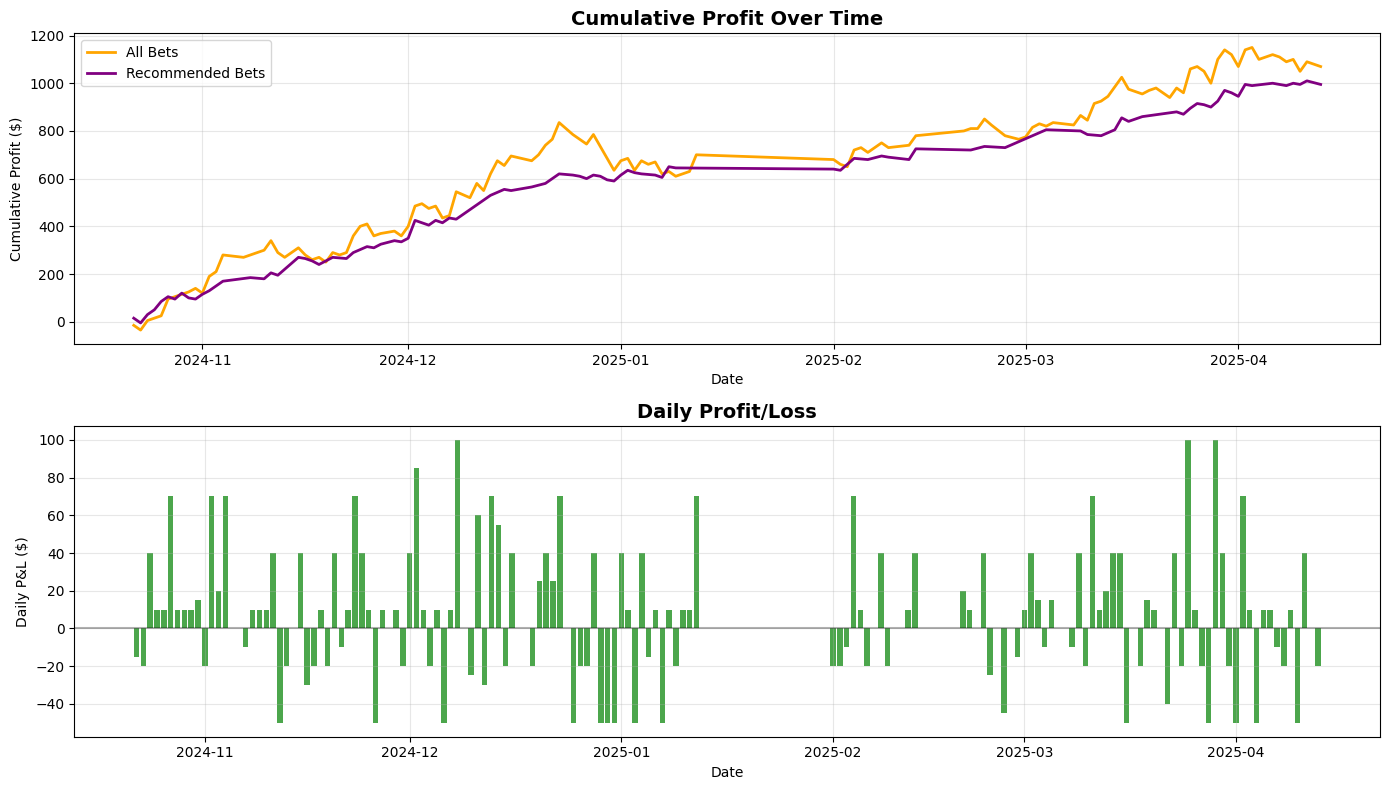

In [12]:
all_metrics = calculate3LegMetrics(final_results, stake=5)

# Calculate metrics for recommended bets only
recommended = final_results[final_results['parlay_recommendation'] == 1]
rec_metrics = calculate3LegMetrics(recommended, stake=5)

# Display comprehensive results
print("=" * 60)
print("           COMPREHENSIVE BETTING ANALYSIS")
print("=" * 60)

if all_metrics:
    print(f"\n ALL BETS ANALYSIS:")
    print(f"   Total Bets: {all_metrics['total_bets']:,}")
    print(f"   Wins: {all_metrics['total_wins']:,}")
    print(f"   Hit Rate: {all_metrics['win_rate']:.2%}")
    print(f"   Total Profit: ${all_metrics['total_profit']:,.2f}")
    print(f"   Total Staked: ${all_metrics['total_staked']:,.2f}")
    print(f"   ROI: {all_metrics['roi_percent']:.2f}%")
    print(f"   Volatility: ${all_metrics['volatility']:.2f}")
    print(f"   Max Drawdown: ${all_metrics['max_drawdown']:.2f}")
    print(f"   Sharpe Ratio: {all_metrics['sharpe_ratio']:.3f}")
    
    # Display probability metrics
    if 'probability_metrics' in all_metrics and 'error' not in all_metrics['probability_metrics']:
        prob_metrics = all_metrics['probability_metrics']
        print(f"\n   PROBABILITY METRICS:")
        print(f"   Brier Score: {prob_metrics.get('brier_score', 'N/A'):.4f} (lower is better)")
        print(f"   Log Loss: {prob_metrics.get('log_loss', 'N/A'):.4f} (lower is better)")
        if not np.isnan(prob_metrics.get('auc_roc', np.nan)):
            print(f"   AUC-ROC: {prob_metrics.get('auc_roc', 'N/A'):.4f} (higher is better)")
        else:
            print(f"   AUC-ROC: NaN ({prob_metrics.get('auc_roc_note', 'Only one class present')})")
        print(f"   Samples: {prob_metrics.get('n_samples', 'N/A')}")

if rec_metrics:
    print(f"\n RECOMMENDED BETS ANALYSIS (Edge > 3.5):")
    print(f"   Total Bets: {rec_metrics['total_bets']:,}")
    print(f"   Wins: {rec_metrics['total_wins']:,}")
    print(f"   Hit Rate: {rec_metrics['win_rate']:.2%}")
    print(f"   Total Profit: ${rec_metrics['total_profit']:,.2f}")
    print(f"   Total Staked: ${rec_metrics['total_staked']:,.2f}")
    print(f"   ROI: {rec_metrics['roi_percent']:.2f}%")
    print(f"   Volatility: ${rec_metrics['volatility']:.2f}")
    print(f"   Max Drawdown: ${rec_metrics['max_drawdown']:.2f}")
    print(f"   Sharpe Ratio: {rec_metrics['sharpe_ratio']:.3f}")
    
    # Display probability metrics for recommended bets
    if 'probability_metrics' in rec_metrics and 'error' not in rec_metrics['probability_metrics']:
        rec_prob_metrics = rec_metrics['probability_metrics']
        print(f"\n   PROBABILITY METRICS:")
        print(f"   Brier Score: {rec_prob_metrics.get('brier_score', 'N/A'):.4f} (lower is better)")
        print(f"   Log Loss: {rec_prob_metrics.get('log_loss', 'N/A'):.4f} (lower is better)")
        if not np.isnan(rec_prob_metrics.get('auc_roc', np.nan)):
            print(f"   AUC-ROC: {rec_prob_metrics.get('auc_roc', 'N/A'):.4f} (higher is better)")
        else:
            print(f"   AUC-ROC: NaN ({rec_prob_metrics.get('auc_roc_note', 'Only one class present')})")
        print(f"   Samples: {rec_prob_metrics.get('n_samples', 'N/A')}")

# Plots cumulative profit over time
if all_metrics and not all_metrics['daily_pnl'].empty:
    plt.figure(figsize=(14, 8))
    
    plt.subplot(2, 1, 1)
    plt.plot(all_metrics['daily_pnl']['date'], all_metrics['daily_pnl']['cumulative_profit'], 
             linewidth=2, label='All Bets', color='orange')
    if rec_metrics and not rec_metrics['daily_pnl'].empty:
        plt.plot(rec_metrics['daily_pnl']['date'], rec_metrics['daily_pnl']['cumulative_profit'], 
                 linewidth=2, label='Recommended Bets', color='purple')
    plt.title('Cumulative Profit Over Time', fontsize=14, fontweight='bold')
    plt.xlabel('Date')
    plt.ylabel('Cumulative Profit ($)')
    plt.legend()
    plt.grid(True, alpha=0.3)
    
    plt.subplot(2, 1, 2)
    plt.bar(all_metrics['daily_pnl']['date'], all_metrics['daily_pnl']['profit'], 
            alpha=0.7, label='Daily P&L', color='green')
    plt.title('Daily Profit/Loss', fontsize=14, fontweight='bold')
    plt.xlabel('Date')
    plt.ylabel('Daily P&L ($)')
    plt.axhline(y=0, color='black', linestyle='-', alpha=0.3)
    plt.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()
